# Bluesky Data Science
## Part 03 - Social Network Analysis of Follow Relationships

June 2026
Copyright and distributed under an [MIT License](https://opensource.org/licenses/MIT)

*An [R Markdown counterpart](../../RMarkdown/Part%2003%20-%20Social%20Network%20Analysis/Part%2003%20-%20Social%20Network%20Analysis.Rmd) of this notebook, using the [bskyr](https://christophertkenny.com/bskyr/) package, lives in the parallel `RMarkdown/` directory.*


## Background

> **tl;dr**: We will retrieve follow relationships from Bluesky's public APIs, build a directed ego network around a seed account in NetworkX, and analyze its structure with degree distributions, centrality measures, community detection, and visualization.

Social media platforms are, first and foremost, *social networks*: who follows whom shapes what information people see, whose voices get amplified, and how communities form. For fifteen years Twitter was the model organism for studying these questions — Kwak et al. (2010) famously crawled the *entire* Twitter follow graph (41.7 million users and 1.47 billion edges!) and asked whether Twitter was a social network or a news medium. That era ended when Twitter's API was enclosed behind a paywall.

Bluesky is different by design. Because the [AT Protocol](https://atproto.com) stores every follow as a public record in users' [data repositories](https://atproto.com/guides/data-repos), **the entire follow graph is publicly readable** — no special research access, no API tier negotiations, no rate-limited "academic track" that can be revoked. The [official API documentation](https://docs.bsky.app) describes the endpoints we will use, and the [atproto Python SDK](https://atproto.blue) wraps them in convenient methods. This makes Bluesky an unusually open playground for social network analysis.

We obviously won't crawl the whole graph in a tutorial. Instead we'll build an **ego network**: the local neighborhood of a single seed account (the "ego"), the accounts it connects to (the "alters"), and the ties *among* those alters. Ego networks are a classic research design in their own right — sociologists have used them for decades to study social support, homophily, and brokerage — and they're a manageable way to learn the core toolkit of network analysis.

If network analysis itself is new to you, two free and unusually readable companions to this notebook are Easley & Kleinberg's [*Networks, Crowds, and Markets*](https://www.cs.cornell.edu/home/kleinber/networks-book/) (especially Chapters 1–3 on graphs, ties, and triadic closure) and Menczer, Fortunato & Davis's [*A First Course in Network Science*](https://cambridgeuniversitypress.github.io/FirstCourseNetworkScience/), whose examples use the same NetworkX library we do. We will link to specific chapters and documentation pages as each concept appears.

### Learning objectives

By the end of this notebook you will be able to:

1. Retrieve follow relationships with `get_follows` and `get_followers`, paginating with cursors.
2. Design a defensible crawl: sample alters with a seeded random number generator and articulate the **boundary specification problem**.
3. Build a directed 1.5-degree ego network as a NetworkX `DiGraph`, with node attributes hydrated via batched `get_profiles` calls.
4. Describe a network with density, reciprocity, and in/out-degree distributions.
5. Compare what in-degree, betweenness, and PageRank centrality each capture.
6. Detect communities with the Louvain algorithm and characterize them.
7. Visualize a network with attribute-based styling and persist it to edge and node lists for reproducible reanalysis.

## Setup

We need three workhorse libraries, all installed via `requirements.txt` in Part 00:

* [**Pandas**](https://pandas.pydata.org/docs/) for tables — every list of accounts and every network statistic eventually lands in a DataFrame.
* [**NetworkX**](https://networkx.org/documentation/stable/) for graphs. NetworkX is the standard pure-Python network library: it represents networks as graph objects whose nodes and edges can carry arbitrary attributes, and it ships implementations of essentially every classic algorithm. Version 3.x includes Louvain community detection under [`networkx.community`](https://networkx.org/documentation/stable/reference/algorithms/community.html), so we need no extra packages.
* [**Matplotlib**](https://matplotlib.org/stable/) for figures, which NetworkX uses as its drawing backend.

We also import `json` and `datetime` up front: when we save our network later, we will write a small metadata file recording when and how it was collected.

In [1]:
# Saved metadata is JSON; collection dates need datetimes
import json
from datetime import datetime, timezone

# DataFrames
import pandas as pd

# Network analysis
import networkx as nx

# Data visualization
%matplotlib inline
import matplotlib.pyplot as plt

print(f"NetworkX version: {nx.__version__}")

NetworkX version: 3.6.1


As in every part of this series, the helper module [`bsky_client.py`](bsky_client.py) gives us a client from the [atproto Python SDK](https://atproto.blue): if an `atproto.json` credentials file exists it logs in, and otherwise it falls back to the unauthenticated **public AppView** (`https://public.api.bsky.app`) — the public, read-only server behind Bluesky's [HTTP API](https://docs.bsky.app/docs/category/http-reference). Everything in this notebook works without logging in — the follow graph is public — except one endpoint we'll flag below.

In [2]:
from bsky_client import get_client, is_authenticated

client = get_client()

No atproto.json found: using the unauthenticated public AppView.
Read endpoints work; search and write endpoints require logging in.


## 1. The follow-graph endpoints

Two endpoints expose the follow graph from either direction:

* [`get_follows` / `app.bsky.graph.getFollows`](https://docs.bsky.app/docs/api/app-bsky-graph-get-follows) — the accounts an actor **follows** (its "out-edges")
* [`get_followers` / `app.bsky.graph.getFollowers`](https://docs.bsky.app/docs/api/app-bsky-graph-get-followers) — the accounts that **follow** an actor (its "in-edges")

(Two pieces of vocabulary. An **actor** is the API's word for an account, identified by handle or DID. And each endpoint has two names because the SDK exposes a Python method for an underlying **lexicon** — the AT Protocol's [schema language](https://atproto.com/guides/lexicon) that formally defines every endpoint's inputs and outputs. The linked lexicon pages are the authoritative reference for what each call accepts and returns.)

Both endpoints return at most 100 accounts per call. To get more we use the **cursor** pagination pattern from Part 01: a cursor is an opaque bookmark the server attaches to each page of results; pass it back with your next request to receive the page after it, and repeat until a response arrives with no cursor at all. Let's look at a single small page first.

In [3]:
follows_page = client.get_follows(actor='nytimes.com', limit=10)

for follow in follows_page.follows:
    print(f"{follow.did}  →  {follow.handle}")

did:plc:lpxsmao5tqprpwxlx4jyvqeu  →  jasonzinoman.bsky.social
did:plc:gcyzqzncdx5baatmeflwxfkh  →  esullivannyt.bsky.social
did:plc:s4qxsuvvxuo72gpqoyhxnezl  →  risenc.bsky.social
did:plc:dtxwxb2zy2pgzenlm4ljhyb5  →  michaelkruse.bsky.social
did:plc:owcsizryev3d4ehe5s4jvkb2  →  lmcgaughy.bsky.social
did:plc:fqoiedutu4lfeadb5s6d4vgi  →  kchang.bsky.social
did:plc:dfyvadpfqliks77dxk7ewb6c  →  sherylnyt.bsky.social
did:plc:a7lx4zo7ibxpkvmty6cww3ot  →  eavis.com
did:plc:zogxbtj2d2n52hvazx22vqli  →  gettingviggy.bsky.social
did:plc:y7a3g5yqsfrcph5orcyrznji  →  pambelluck.bsky.social


Notice that every account comes with two identifiers. The **DID** ("decentralized identifier", `did:plc:...`) is a permanent, machine-readable identifier that stays with an account for life — see the [DID specification](https://atproto.com/specs/did). The **handle** (`nytimes.com`) is the human-readable name, but [handles](https://atproto.com/specs/handle) are just domain names and can change at any time — many accounts start at a `.bsky.social` handle and later switch to their own domain. Throughout this notebook we build the network on DIDs and keep handles around purely as labels, a habit that pays off in any longitudinal design: if you collect a network today and revisit it next year, DIDs will still match even where handles have churned.

The response also carries the pagination cursor. Let's use it to fetch the next page and confirm it picks up where the first left off.

In [4]:
print('Cursor for the next page:', follows_page.cursor)

next_page = client.get_follows(actor='nytimes.com', limit=10,
                               cursor=follows_page.cursor)

print('First account on the next page:', next_page.follows[0].handle)

Cursor for the next page: 3ml2whznfiw2s


First account on the next page: dustinvolz.bsky.social


[`get_followers`](https://docs.bsky.app/docs/api/app-bsky-graph-get-followers) works identically in the other direction: same `actor` parameter, same 100-per-page limit, same cursor. The only difference is that the accounts come back in a field named `followers` rather than `follows`.

In [5]:
followers_page = client.get_followers(actor='nytimes.com', limit=10)

[follower.handle for follower in followers_page.followers]

['dannyjambrose2026.bsky.social',
 'susannadesi.bsky.social',
 'zerrincebeci.bsky.social',
 'hitoha.moe',
 'goodllama.bsky.social']

### `get_known_followers` requires authentication

There is a third graph endpoint, [`get_known_followers` / `app.bsky.graph.getKnownFollowers`](https://docs.bsky.app/docs/api/app-bsky-graph-get-known-followers), which returns the followers of an account *that you also follow* — the "followed by people you know" feature in the app. Because it is defined relative to **your** follow list, it only makes sense (and only works) when you are logged in, so we wrap it in the usual `is_authenticated` guard: with credentials the cell runs, and without them it explains itself and moves on instead of crashing.

In [6]:
if is_authenticated(client):
    known = client.app.bsky.graph.get_known_followers({
        'actor': 'bsky.app',
        'limit': 10,
    })
    print(f"{len(known.followers)} followers of bsky.app that you follow:")
    for follower in known.followers:
        print(' ', follower.handle)
else:
    print("get_known_followers requires authentication: it returns the")
    print("followers of an account that *you* also follow, so the server")
    print("needs to know who you are. Save an atproto.json file (Part 00)")
    print("and re-run this cell to try it.")

get_known_followers requires authentication: it returns the
followers of an account that *you* also follow, so the server
needs to know who you are. Save an atproto.json file (Part 00)
and re-run this cell to try it.


## 2. Designing the crawl: boundary specification and sampling

Before writing a crawler, we have to answer a deceptively hard question: **who counts as "in" the network?** The follow graph is effectively infinite — every alter has alters, who have alters, and within a few hops you reach most of the platform. Laumann, Marsden, and Prensky (1983) called this the **boundary specification problem**, and every network study has to solve it explicitly. A boundary is a *research design decision*, not a property of the data.

Our design is a **1.5-degree ego network**:

* **Ego**: a single seed account. We use `nytimes.com` (The New York Times — an institutional account whose follows are professional relationships: journalists, sister accounts, and peer organizations).
* **Alters**: a random sample of the accounts the ego follows.
* **Edges**: every follow relationship *among* {ego + alters}. It's called "1.5 degrees" because we observe ego→alter ties **and** alter↔alter ties, but nothing outside that set.

Why "1.5" rather than 1 or 2? A *1-degree* design would record only the ego's own ties — a star shape with no internal structure to analyze. A full *2-degree* design would add the alters' alters as nodes, exploding the crawl by another factor of a hundred or more. Observing the ties *among* the first-degree alters is the halfway point that gives ego networks their analytical bite at a manageable cost.

First, let's see how big the ego's neighborhood is by fetching its profile with [`get_profile` / `app.bsky.actor.getProfile`](https://docs.bsky.app/docs/api/app-bsky-actor-get-profile) (familiar from Part 00), which reports total follows and followers.

In [7]:
EGO_HANDLE = 'nytimes.com'

ego_profile = client.get_profile(EGO_HANDLE)
ego_did = ego_profile.did

print(f"{EGO_HANDLE} ({ego_did})")
print(f"Follows {ego_profile.follows_count:,} accounts; "
      f"followed by {ego_profile.followers_count:,}")

nytimes.com (did:plc:eclio37ymobqex2ncko63h4r)
Follows 116 accounts; followed by 1,326,483


### The helper module

The crawling logic lives in this part's helper module, [`ego_network.py`](ego_network.py), so the notebook can stay focused on analysis. It has four functions, each a pattern you've seen before:

* `fetch_follows(client, actor, max_pages)` — the cursor-pagination loop from Part 01, with a polite `time.sleep(0.1)` between pages
* `sample_alters(follows, k, seed)` — a seeded simple random sample of alters
* `build_ego_network(client, ego_did, alters, max_pages_per_alter)` — the crawl itself, returning a NetworkX [`DiGraph`](https://networkx.org/documentation/stable/reference/classes/digraph.html)
* `add_profile_attributes(client, G)` — node attributes via batched `get_profiles` calls

Open the file and read it — it's short, and every API call in it is a client method documented in the [atproto SDK](https://atproto.blue). Let's fetch the ego's complete follow list (about 25 paginated calls, so this cell takes a few seconds).

In [8]:
from ego_network import (fetch_follows, sample_alters,
                         build_ego_network, add_profile_attributes)

ego_follows = fetch_follows(client, ego_did)

print(f"Retrieved {len(ego_follows):,} follows")

Retrieved 116 follows


### Why sample?

The ego follows ~2,400 accounts. Crawling *every* alter's follow list would mean tens of thousands of API calls — perfectly legal against a public API, but slow, impolite, and far more data than a tutorial needs. Instead we draw a **simple random sample of 100 alters**.

Two things make this defensible rather than arbitrary:

1. **It's a probability sample.** Every alter has an equal chance of inclusion, so sample statistics (density, reciprocity, degree distributions) estimate the corresponding quantities in the full 1.5-degree network, with quantifiable sampling error. Contrast this with convenience choices like "the 100 most recent follows" (biased toward new ties) or "the 100 most-followed alters" (biased toward celebrities).
2. **It's reproducible.** We seed the random number generator, so anyone re-running this notebook against the same follow list draws the same sample.

Sampling is itself a second boundary decision stacked on the first — our network is "the ego plus a seeded random 100 of its alters," and every number we compute below is conditional on that definition.

In [9]:
N_ALTERS = 100
SEED = 42

alters = sample_alters(ego_follows, k=N_ALTERS, seed=SEED)

print(f"Sampled {len(alters)} alters. The first ten:")
for alter in alters[:10]:
    print(' ', alter['handle'])

Sampled 100 alters. The first ten:
  carlzimmer.com
  johncarreyrou.bsky.social
  michaelkruse.bsky.social
  kateconger.com
  conordougherty.bsky.social
  mikeisaac.bsky.social
  ering.bsky.social
  malachy.bsky.social
  charliesavage.bsky.social
  sapna.bsky.social


## 3. Building the 1.5-degree ego network

Now the crawl. For each sampled alter, `build_ego_network`:

1. fetches the first **2 pages (~200 accounts)** of that alter's follows, sleeping 0.1 s between calls,
2. keeps only the follows that point back **inside** our node set of {ego + 100 alters}, and
3. adds them as directed edges (follower → followed).

The result is a NetworkX [`DiGraph`](https://networkx.org/documentation/stable/reference/classes/digraph.html) — a *directed* graph, which matters because following is asymmetric: A following B does not imply B follows A. The ego's edges to all 100 alters are added directly, since the alters were sampled from the ego's own follow list.

One honest limitation: capping each alter at ~200 follows (returned newest-first) means we will miss some within-network edges from prolific followers — a **measurement truncation** that trades completeness for politeness. With ~2 calls per alter the whole crawl is about 200 requests and takes a minute or two. (If an alter's account has been deleted or deactivated since we sampled it, the helper skips it gracefully rather than crashing — live data always has casualties.)

In [10]:
G = build_ego_network(client, ego_did, alters, max_pages_per_alter=2)

print(f"\nDone: {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

Crawled 20/100 alters: 101 nodes, 332 edges


  ! skipping jeffcmays.bsky.social: 


Crawled 40/100 alters: 101 nodes, 662 edges


Crawled 60/100 alters: 101 nodes, 893 edges


Crawled 80/100 alters: 101 nodes, 1112 edges


Crawled 100/100 alters: 101 nodes, 1311 edges

Done: 101 nodes and 1311 edges


### Node attributes with batched `get_profiles`

A graph of bare DIDs isn't much to look at. The [`get_profiles` / `app.bsky.actor.getProfiles`](https://docs.bsky.app/docs/api/app-bsky-actor-get-profiles) endpoint **hydrates** — fills in the full details for — up to **25 profiles per call**, so we can decorate all ~101 nodes with handles and public counts in just five requests, far better than 101 individual `get_profile` calls. In NetworkX this metadata lives as **node attributes**: a small dictionary attached to each node, which we will lean on later for labeling, community characterization, and saving.

In [11]:
n_profiles = add_profile_attributes(client, G)

print(f"Hydrated {n_profiles} profiles "
      f"({-(-G.number_of_nodes() // 25)} batched calls)\n")
print("The ego's node attributes:")
G.nodes[ego_did]

Hydrated 101 profiles (5 batched calls)

The ego's node attributes:


{'handle': 'nytimes.com',
 'followers_count': 1326483,
 'follows_count': 116,
 'posts_count': 37642}

Let's also record when and how we collected this network — a habit from Part 01. Handles change, follows churn, and accounts get deleted, so a network snapshot without a timestamp and parameters is unreproducible by definition.

In [12]:
collection_metadata = {
    'ego_handle': EGO_HANDLE,
    'ego_did': ego_did,
    'collected_at': datetime.now(timezone.utc).isoformat(timespec='seconds'),
    'ego_follows_at_collection': len(ego_follows),
    'n_alters_sampled': N_ALTERS,
    'sampling_seed': SEED,
    'max_pages_per_alter': 2,
}

with open('data/collection_metadata.json', 'w') as f:
    json.dump(collection_metadata, f, indent=2)

collection_metadata

{'ego_handle': 'nytimes.com',
 'ego_did': 'did:plc:eclio37ymobqex2ncko63h4r',
 'collected_at': '2026-06-10T16:23:02+00:00',
 'ego_follows_at_collection': 116,
 'n_alters_sampled': 100,
 'sampling_seed': 42,
 'max_pages_per_alter': 2}

## 4. Describing the network

The first thing to do with any network is to describe its basic shape — the network analogue of looking at means and histograms before fitting a model.

* [**Density**](https://networkx.org/documentation/stable/reference/generated/networkx.classes.function.density.html) is the fraction of possible directed edges that actually exist: with $n$ nodes there are $n(n-1)$ possible directed ties, and density is the share of them we observed, from 0 (no edges) to 1 (everyone follows everyone). Ego networks are denser than the platform at large — by construction, everyone here is at most two steps from the ego.
* [**Reciprocity**](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.reciprocity.reciprocity.html) is the fraction of edges that are returned: if A follows B, does B follow A back? Kwak et al. (2010) found Twitter's reciprocity was strikingly low (~22%), which they read as evidence that Twitter functioned more like a *news medium* (asymmetric subscription) than a *social network* (mutual friendship). Computing the same statistic here lets you test where this Bluesky neighborhood falls.

In [13]:
print(f"Nodes:       {G.number_of_nodes()}")
print(f"Edges:       {G.number_of_edges()}")
print(f"Density:     {nx.density(G):.3f}")
print(f"Reciprocity: {nx.reciprocity(G):.3f}")

Nodes:       101
Edges:       1311
Density:     0.130
Reciprocity: 0.301


Read these two numbers against external benchmarks before moving on. Density here is far higher than the platform as a whole — the full Twitter graph Kwak et al. crawled had a density around $10^{-7}$ — because an ego network is, by construction, a dense pocket of accounts sharing a common anchor. And compare the reciprocity to Kwak et al.'s 22% for Twitter at large: a personal follow neighborhood of peers and colleagues usually reciprocates at a much higher rate. This is your first concrete lesson that *where you draw the boundary changes the substantive conclusion* — the same statistic, computed on differently bounded networks, tells different stories.

### Degree distributions

In a directed follow graph each node has two **degrees**: **in-degree** (followers within the network — a measure of local audience) and **out-degree** (follows within the network — a measure of local attention paid). Note the qualifier *within the network*: an account with millions of platform-wide followers can have a tiny in-degree here if few of our sampled alters happen to follow it. `G.in_degree()` and `G.out_degree()` are NetworkX [degree views](https://networkx.org/documentation/stable/reference/classes/generated/networkx.DiGraph.in_degree.html); wrapping them in `dict` and then `pd.Series` turns them into labeled columns Pandas can summarize and plot.

In [14]:
in_degree = pd.Series(dict(G.in_degree()), name='in_degree')
out_degree = pd.Series(dict(G.out_degree()), name='out_degree')

pd.concat([in_degree.describe(), out_degree.describe()], axis=1).round(2)

,in_degree,out_degree
count,101.00,101.00
mean,12.98,12.98
std,7.30,14.84
min,1.00,0.00
25%,8.00,3.00
50%,13.00,9.00
75%,16.00,16.00
max,39.00,100.00


The summary table is exact but hard to see shape in, so we also draw histograms. One detail in the table is worth pausing on because it surprises almost everyone at first: the **means of in-degree and out-degree are always identical**. Every directed edge contributes exactly one out-degree (to its source) and one in-degree (to its target), so the two totals — and therefore the means — must match. The *distributions* around that shared mean can still look very different, and that is what the histograms reveal.

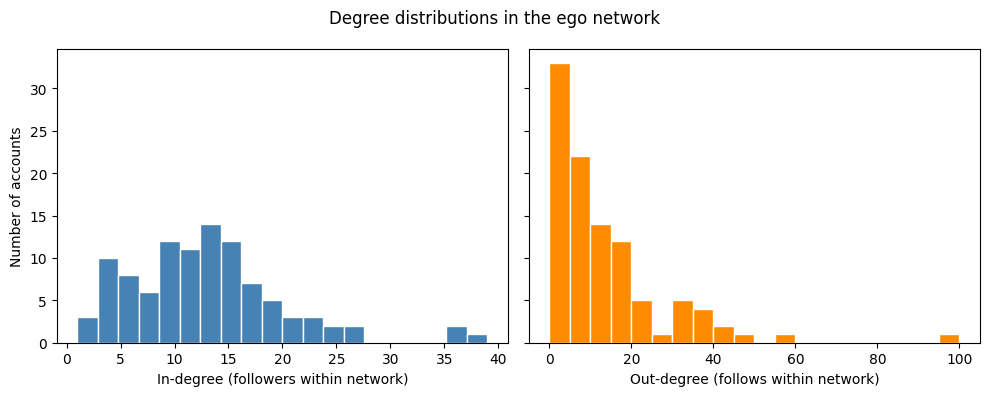

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

in_degree.plot.hist(bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_xlabel('In-degree (followers within network)')
axes[0].set_ylabel('Number of accounts')

out_degree.plot.hist(bins=20, ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_xlabel('Out-degree (follows within network)')

fig.suptitle('Degree distributions in the ego network')
plt.tight_layout()

Degree distributions on social platforms are famously **heavy-tailed**: most accounts have few connections while a handful have many. The conventional diagnostic is to plot the distribution on **log-log axes**, where a heavy tail appears as a slowly decaying, roughly linear scatter. With only ~100 nodes our plot will be noisy — a genuine power-law test needs orders of magnitude more data (and more care) — but the shape is still instructive.

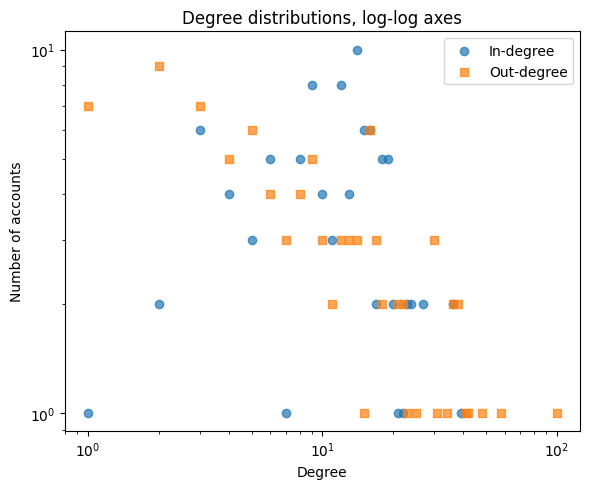

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))

for series, marker, label in [(in_degree, 'o', 'In-degree'),
                              (out_degree, 's', 'Out-degree')]:
    counts = series.value_counts().sort_index()
    counts = counts[counts.index > 0]          # log scale can't show degree 0
    ax.scatter(counts.index, counts.values, marker=marker, alpha=0.7, label=label)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Degree')
ax.set_ylabel('Number of accounts')
ax.set_title('Degree distributions, log-log axes')
ax.legend()
plt.tight_layout()

Even at this small scale you can usually see the asymmetry: in-degree stretches further to the right (a few locally prominent accounts collect many followers within the network), while out-degree is more tightly bunched — partly a real social pattern, partly because our crawl truncated each alter's follow list. One caution about vocabulary: eyeballing a roughly straight line on log-log axes is *suggestive* of a heavy tail, not a test of a power law. Rigorous power-law fitting (Clauset, Shalizi & Newman 2009; implemented in the [`powerlaw`](https://pypi.org/project/powerlaw/) package) needs orders of magnitude more data than 100 nodes.

## 5. Centrality: who matters, and in what sense?

"Importance" in a network is not one thing. Different **centrality** measures — formal scores of how structurally important each node is — capture different intuitions, and they often disagree in informative ways:

* **In-degree** — raw audience *within this network*: how many of these accounts follow you. Simple, local, easy to game.
* [**Betweenness**](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.centrality.betweenness_centrality.html) — brokerage: the fraction of shortest paths between other pairs of nodes that pass through you. High-betweenness accounts bridge otherwise separate regions of the network and would fragment it if removed (Granovetter's "weak ties" logic).
* [**PageRank**](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.link_analysis.pagerank_alg.pagerank.html) — recursive prestige: being followed by accounts that are themselves well-followed counts for more. This is the random-surfer model originally built for the web graph; Easley & Kleinberg's [Chapter 14](https://www.cs.cornell.edu/home/kleinber/networks-book/networks-book-ch14.pdf) gives a gentle derivation.

Kwak et al. (2010) found that on Twitter, follower counts and PageRank produced very similar rankings, while ranking by retweets surfaced a *different* set of accounts — a reminder that "influence" depends on the relation you measure. Let's compute all three and put them side by side in a DataFrame.

In [17]:
centrality = pd.DataFrame({
    'handle': pd.Series(nx.get_node_attributes(G, 'handle')),
    'in_degree': pd.Series(dict(G.in_degree())),
    'betweenness': pd.Series(nx.betweenness_centrality(G)),
    'pagerank': pd.Series(nx.pagerank(G)),
})

centrality.sort_values('pagerank', ascending=False).head().round(4)

,handle,in_degree,betweenness,pagerank
did:plc:eclio37ymobqex2ncko63h4r,nytimes.com,39,0.3005,0.0499
did:plc:tm256llkpggffiiuwk4tgiej,peterbakernyt.bsky.social,36,0.0372,0.0258
did:plc:llg72eynrn7qxdanzhytpz76,lydiadepillis.bsky.social,16,0.0550,0.0258
did:plc:jjq37jze7ynm7uzalnrk5au5,charliesavage.bsky.social,27,0.0119,0.0227
did:plc:agiex7zg5lulytsxulmalrgz,ericlipton.nytimes.com,36,0.0249,0.0216


One caveat before we rank anyone: **the ego is central by construction.** We built the network around it, and it follows all 100 alters, so its out-degree and betweenness are artifacts of the research design rather than findings. Standard practice in ego-network analysis is to examine the structure *among the alters* with the ego set aside, so we drop the ego from the leaderboard.

In [18]:
alters_only = centrality.drop(ego_did)

top10 = pd.DataFrame({
    measure: alters_only.sort_values(measure, ascending=False)['handle']
                        .head(10).values
    for measure in ['in_degree', 'betweenness', 'pagerank']
}, index=pd.RangeIndex(1, 11, name='rank'))

top10

,in_degree,betweenness,pagerank
rank,,,
1,ericlipton.nytimes.com,lydiadepillis.bsky.social,peterbakernyt.bsky.social
2,peterbakernyt.bsky.social,michaelkruse.bsky.social,lydiadepillis.bsky.social
3,charliesavage.bsky.social,peterbakernyt.bsky.social,charliesavage.bsky.social
4,kateconger.com,benmullin.bsky.social,ericlipton.nytimes.com
5,benmullin.bsky.social,teddyschleifer.bsky.social,colbylsmith.bsky.social
6,maggieastor.bsky.social,ericlipton.nytimes.com,teddyschleifer.bsky.social
7,davidenrich.bsky.social,dodai.bsky.social,benmullin.bsky.social
8,kashhill.bsky.social,ewong.bsky.social,dodai.bsky.social
9,rmac.bsky.social,kateconger.com,rmac.bsky.social


Read the three columns against each other. In-degree and PageRank usually overlap heavily (as on Twitter), surfacing the accounts most widely followed within this neighborhood. The betweenness column is where the surprises live: accounts that rank high there but lower on in-degree are **bridges** — they connect clusters of the ego's world that otherwise wouldn't touch. We'll see those clusters explicitly in the next section.

## 6. Community detection

Social networks are clumpy: ties concentrate within groups — colleagues, topical scenes, language communities — with sparser connections between them. **Community detection** algorithms recover these groups from structure alone, with no labels or attributes. We'll use the **Louvain algorithm** (Blondel et al. 2008), a fast heuristic available as [`nx.community.louvain_communities`](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.louvain.louvain_communities.html), which searches for the partition maximizing [**modularity**](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.quality.modularity.html): the extent to which edges fall within communities rather than between them, relative to what we'd expect by chance. Modularity ranges from −0.5 to 1, and in practice values above roughly 0.3 signal meaningful community structure. Louvain is a randomized heuristic, so we pass a `seed` to make the partition reproducible.

Louvain operates on undirected graphs, so we first take the [**undirected projection**](https://networkx.org/documentation/stable/reference/classes/generated/networkx.DiGraph.to_undirected.html) of our `DiGraph` — an edge between A and B if either follows the other. We lose direction information, but for "who clusters with whom" that's an acceptable simplification. (Conover et al. (2011) showed on Twitter how much the choice of relation matters: political retweet networks split into two starkly polarized camps, while mention networks did not — same users, different graph, different communities.)

In [19]:
G_undirected = G.to_undirected()

communities = nx.community.louvain_communities(G_undirected, seed=SEED)
communities = sorted(communities, key=len, reverse=True)

# Record each node's community as an attribute, numbered largest-first
for community_id, members in enumerate(communities):
    for did in members:
        G.nodes[did]['community'] = community_id

print(f"Louvain found {len(communities)} communities")
print(f"Modularity:   "
      f"{nx.community.modularity(G_undirected, communities):.3f}")

Louvain found 4 communities
Modularity:   0.187


A modularity comfortably above the ~0.3 rule of thumb tells us the partition captures real clumpiness rather than noise. Next question: how big are the communities? Louvain typically returns a few large communities plus a tail of small ones — sometimes "communities" of one or two poorly connected nodes, an artifact worth remembering before you interpret every cluster as a genuine social scene.

In [20]:
community_sizes = pd.Series({i: len(members)
                             for i, members in enumerate(communities)},
                            name='size').rename_axis('community')
community_sizes

community
0    41
1    31
2    15
3    14
Name: size, dtype: int64

What *are* these communities? The algorithm only sees edges, so interpretation is on us. A quick, low-judgment way to characterize each one is to list its most-followed members (using the platform-wide `followers_count` we hydrated earlier) and let readers recognize the scene for themselves. First we flatten the node attributes into a DataFrame we'll reuse for saving.

In [21]:
nodes_df = (
    pd.DataFrame.from_dict(dict(G.nodes(data=True)), orient='index')
      .rename_axis('did')
      .reset_index()
)

nodes_df.head()

,did,handle,followers_count,follows_count,posts_count,community
0,did:plc:eclio37ymobqex2ncko63h4r,nytimes.com,1326483,116,37642,0
1,did:plc:xqrqlxsfingcrocs7dut7rav,carlzimmer.com,53207,1673,24612,0
2,did:plc:5tpzxot6376arrg3wtt6q3th,johncarreyrou.bsky.social,1790,203,3,0
3,did:plc:dtxwxb2zy2pgzenlm4ljhyb5,michaelkruse.bsky.social,7184,1431,2439,0
4,did:plc:5siz7r23475fek2mj6p5zhzw,kateconger.com,162186,643,2036,1


With the node attributes flattened into a DataFrame, characterizing each community takes one line per community: filter to its members and list the five with the largest *platform-wide* follower counts (not the within-network in-degree — we want names a reader might recognize).

In [22]:
largest_communities = pd.DataFrame({
    f"community {i} (n={community_sizes[i]})": (
        nodes_df[nodes_df['community'] == i]
        .nlargest(5, 'followers_count')['handle']
        .reset_index(drop=True)
    )
    for i in range(min(4, len(communities)))
})

largest_communities

,community 0 (n=41),community 1 (n=31),community 2 (n=15),community 3 (n=14)
0,nytimes.com,kateconger.com,theathletic.com,charliesavage.bsky.social
1,peterbakernyt.bsky.social,alissawilkinson.bsky.social,rmac.bsky.social,ericlipton.nytimes.com
2,andrewrsorkin.bsky.social,benmullin.bsky.social,kashhill.bsky.social,dustinvolz.bsky.social
3,davidenrich.bsky.social,ericasimov.bsky.social,mikeisaac.bsky.social,carolrosenbergfeed.bsky.social
4,carlzimmer.com,mikebaker.bsky.social,palafo.bsky.social,julianbarnes.bsky.social


Scanning the columns, each community tends to read as a coherent slice of the ego's social world — different professional, topical, or platform-era circles. This is **homophily** made visible: ties form disproportionately between similar people, so structural clusters end up aligning with shared attributes even though the algorithm never saw any attributes. We'll return to this in Section 9.

## 7. Visualizing the network

A picture ties everything together. We draw the network with a [**spring layout**](https://networkx.org/documentation/stable/reference/generated/networkx.drawing.layout.spring_layout.html) — a physics simulation in which connected nodes attract and all nodes repel, so communities settle into visual clusters — then **color nodes by Louvain community** and **size them by in-degree**, and save the figure alongside our data. NetworkX's [drawing functions](https://networkx.org/documentation/stable/reference/drawing.html) are deliberately basic (for publication-quality graphics researchers often export to [Gephi](https://gephi.org/)), but they are more than enough to read a 100-node structure.

Two practical notes: we compute the layout on the undirected projection with a fixed seed so the picture is reproducible, and we draw edges first, faint and unarrowed, so the lines don't bury the points.

Saved data/ego_network.png


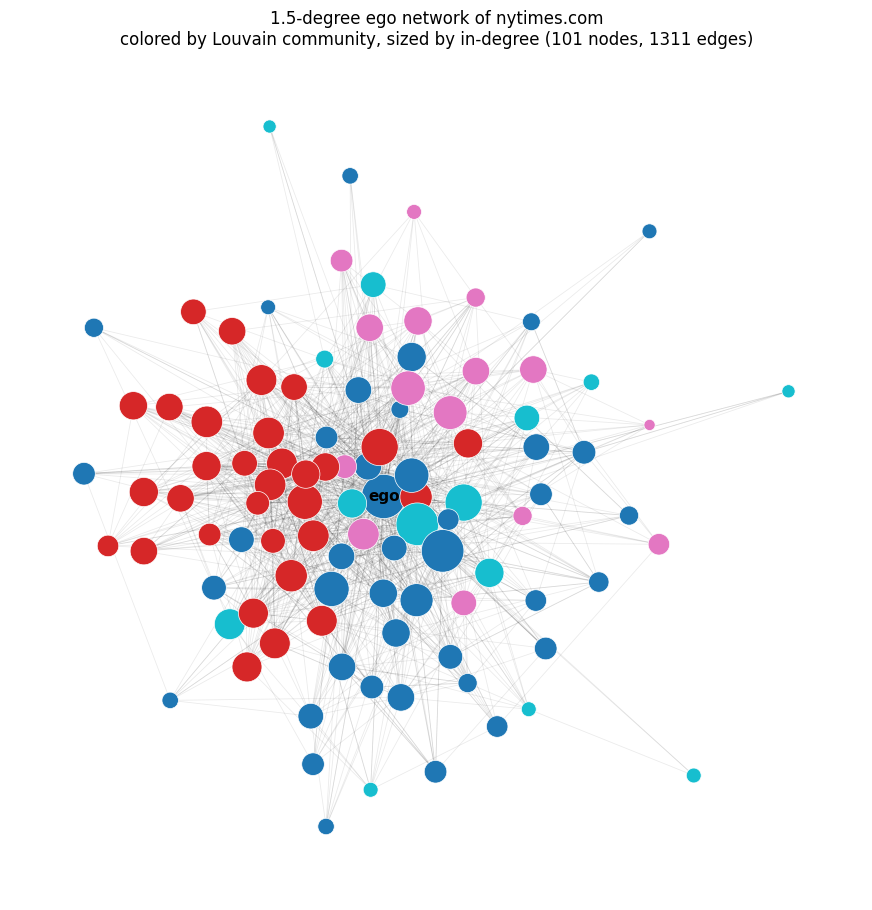

In [23]:
pos = nx.spring_layout(G_undirected, seed=SEED, k=0.35)

node_colors = [G.nodes[node]['community'] for node in G.nodes]
node_sizes = [40 + 25 * G.in_degree(node) for node in G.nodes]

fig, ax = plt.subplots(figsize=(11, 11))

nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.08, width=0.6, arrows=False)
nx.draw_networkx_nodes(G, pos, ax=ax,
                       node_color=node_colors, cmap=plt.cm.tab10,
                       node_size=node_sizes,
                       linewidths=0.5, edgecolors='white')
nx.draw_networkx_labels(G, pos, labels={ego_did: 'ego'},
                        font_size=11, font_weight='bold', ax=ax)

ax.set_title(f"1.5-degree ego network of {EGO_HANDLE}\n"
             f"colored by Louvain community, sized by in-degree "
             f"({G.number_of_nodes()} nodes, {G.number_of_edges()} edges)")
ax.axis('off')

fig.savefig('data/ego_network.png', dpi=150, bbox_inches='tight')
print("Saved data/ego_network.png")
plt.show()

The ego sits near the center — again, by construction — while the colored clusters spread around it. Large nodes deep inside a single-colored region are local hubs of one community; nodes sitting *between* color regions are the same bridges that topped the betweenness ranking.

## 8. Saving and reloading the network

A network analysis you can't re-run is just an anecdote. The standard interchange format is a pair of tidy tables:

* **`edges.csv`** — one row per directed follow: `source_did`, `target_did`
* **`nodes.csv`** — one row per account: `did`, `handle`, the public counts, and the community assignment

Together with `collection_metadata.json` from Section 3, these three files fully describe the snapshot. (NetworkX can also [read and write](https://networkx.org/documentation/stable/reference/readwrite/index.html) graph formats like GraphML and GEXF, which tools such as [Gephi](https://gephi.org/) open directly — but a pair of CSVs is the most portable choice and the friendliest to Pandas.)

In [24]:
edges_df = pd.DataFrame(G.edges(), columns=['source_did', 'target_did'])
edges_df.to_csv('data/edges.csv', index=False)

nodes_df.to_csv('data/nodes.csv', index=False)

print(f"Saved {len(edges_df):,} edges and {len(nodes_df):,} nodes")
edges_df.head()

Saved 1,311 edges and 101 nodes


,source_did,target_did
0,did:plc:eclio37ymobqex2ncko63h4r,did:plc:xqrqlxsfingcrocs7dut7rav
1,did:plc:eclio37ymobqex2ncko63h4r,did:plc:5tpzxot6376arrg3wtt6q3th
2,did:plc:eclio37ymobqex2ncko63h4r,did:plc:dtxwxb2zy2pgzenlm4ljhyb5
3,did:plc:eclio37ymobqex2ncko63h4r,did:plc:5siz7r23475fek2mj6p5zhzw
4,did:plc:eclio37ymobqex2ncko63h4r,did:plc:ta7gamxe7f7gwkibjqir66au


To prove the archive is self-sufficient, let's rebuild the graph **from the saved files alone** and check it matches what we crawled. [`nx.from_pandas_edgelist`](https://networkx.org/documentation/stable/reference/generated/networkx.convert_matrix.from_pandas_edgelist.html) turns the edge table back into a `DiGraph`, and [`nx.set_node_attributes`](https://networkx.org/documentation/stable/reference/generated/networkx.classes.function.set_node_attributes.html) re-attaches the node table. Everything from Section 4 onward could run from here — no API access required — which is exactly what you want when sharing an analysis or returning to it after the live network has churned.

In [25]:
edges_loaded = pd.read_csv('data/edges.csv')
nodes_loaded = pd.read_csv('data/nodes.csv')

G_loaded = nx.from_pandas_edgelist(edges_loaded,
                                   source='source_did', target='target_did',
                                   create_using=nx.DiGraph)
G_loaded.add_nodes_from(nodes_loaded['did'])  # keep any isolated nodes
nx.set_node_attributes(G_loaded, nodes_loaded.set_index('did').to_dict('index'))

same_structure = (set(G_loaded.nodes) == set(G.nodes)
                  and set(G_loaded.edges) == set(G.edges))

print(f"Reloaded:    {G_loaded.number_of_nodes()} nodes, "
      f"{G_loaded.number_of_edges()} edges")
print(f"Matches the crawled graph: {same_structure}")
print(f"Density from file:         {nx.density(G_loaded):.3f}")

Reloaded:    101 nodes, 1311 edges
Matches the crawled graph: True
Density from file:         0.130


And any downstream analysis runs from disk exactly as it ran from the live crawl. As a demonstration, here are the top-5 PageRank accounts recomputed from the reloaded graph — they should match Section 5.

In [26]:
# Any analysis re-runs from disk — e.g., the top-5 PageRank accounts:
pagerank_loaded = pd.Series(nx.pagerank(G_loaded)).drop(ego_did)

for did in pagerank_loaded.nlargest(5).index:
    print(f"{G_loaded.nodes[did]['handle']:<35} "
          f"{pagerank_loaded[did]:.4f}")

peterbakernyt.bsky.social           0.0258
lydiadepillis.bsky.social           0.0258
charliesavage.bsky.social           0.0227
ericlipton.nytimes.com              0.0216
colbylsmith.bsky.social             0.0213


## 9. Research designs with ego networks

What kinds of questions can a design like this answer?

**Ego-network designs.** Long before platform APIs, surveys like the General Social Survey asked respondents to name the people they discuss important matters with, producing exactly this structure: an ego, alters, and alter–alter ties. Classic findings — that ego networks shrank over time, that they are stratified by education, that kin and non-kin play different roles — all come from 1.5-degree data. Platform follow graphs let you collect the same structure for thousands of egos without a survey, at the cost of measuring "follows" rather than "discusses important matters with."

**Homophily.** McPherson, Smith-Lovin, and Cook (2001) summarize one of sociology's most robust findings: ties form disproportionately between similar people ("birds of a feather flock together"). With hydrated node attributes you can quantify it here — do alters in the same Louvain community have more similar follower counts, account ages, or posting languages than alters in different communities? On Twitter, Conover et al. (2011) showed homophily at its starkest: the political retweet network was so segregated that two communities captured nearly the whole graph.

**Triadic closure.** Networks where your friends tend to be friends with each other have many closed triangles. Triadic closure is both a theory of tie formation — you meet friends of friends — and a mechanism platforms actively accelerate through "people you may know" recommenders and, on Bluesky, starter packs. Two standard measurements: [**transitivity**](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.cluster.transitivity.html) is the network-wide share of two-step paths that close into triangles, and the [**average clustering coefficient**](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.cluster.average_clustering.html) asks, node by node, how connected each account's neighbors are to one another, then averages. Let's measure both in our network.

In [27]:
print(f"Transitivity (share of closed triads): "
      f"{nx.transitivity(G_undirected):.3f}")
print(f"Average clustering coefficient:        "
      f"{nx.average_clustering(G_undirected):.3f}")

Transitivity (share of closed triads): 0.373
Average clustering coefficient:        0.494


**And always: the boundary.** Every number above — density, reciprocity, centrality rankings, community count, transitivity — is a property of *the network we specified*, not of "Bluesky." A different ego, a different sample of alters, a deeper crawl, or follower-based (rather than follows-based) edges would yield different numbers. Good network papers state their boundary decision in the first paragraph of the methods section; now you can, too.

## Ethics and limitations

**Network data is always about third parties.** The ego in this notebook is the series' author, who consented to being studied — but the 100 alters and the couple hundred follow relationships among them belong to people who never opted into anything. They are [public records](https://atproto.com/guides/data-repos) under the AT Protocol, yet research consistently finds that users are surprised to learn their public traces are used in research (Fiesler & Proferes 2018). Practical consequences for your own projects:

* **Minimize.** We stored only DIDs, handles, and aggregate public counts — no posts, descriptions, or avatars. Collect the fields your question requires and nothing more.
* **Aggregate when reporting.** We characterized communities by listing their most-followed (i.e., most public-facing) members and offered no commentary on individuals. Prefer community-level and network-level statistics over claims about named people, especially low-follower accounts.
* **Think before you share edge lists.** A follow network of identifiable individuals can reveal affiliations (political, medical, religious) that no single profile discloses. Consider de-identifying DIDs before publishing data, and record your collection date so deletions and unfollows can be honored.
* **Boundary specification is also an ethical decision.** Whoever your crawl touches becomes a research subject. A seeded sample of a consenting ego's follows is a deliberately conservative choice; snowballing outward from strangers raises the stakes with every wave.

**Limitations to keep in view:** our per-alter crawl was truncated at ~200 most-recent follows, so within-network edges from prolific followers are undercounted; the network is a single snapshot of a constantly churning graph; one ego's neighborhood generalizes to nothing beyond itself; and Bluesky's user base — early adopters and waves of Twitter migrants — is not a sample of any broader population.

## Exercises

1. **Change the ego.** Set `EGO_HANDLE` to a different account — your own, or an institutional account like `bsky.app` — and re-run the notebook from Section 2 onward. Pick an ego that follows at least a few hundred accounts so there is something to sample, and compare its density and reciprocity to the numbers above.
2. **Grow (or re-draw) the sample.** Increase `N_ALTERS` to 200 — roughly doubling the crawl to ~400 calls, still polite — or simply change `SEED` and re-run. Which summary statistics stay stable across samples and which jump around? This gives you a hands-on feel for sampling error.
3. **Deepen the crawl.** Raise `max_pages_per_alter` from 2 to 5 and rebuild the network with the same alters and seed. How many within-network edges appear that the shallower crawl missed, and which alters contribute them? This quantifies the measurement-truncation bias discussed in Section 3.
4. **Add a fourth centrality.** Compute [closeness centrality](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.centrality.closeness_centrality.html) (or eigenvector centrality), add it to the Section 5 leaderboard, and compute Spearman rank correlations among all four measures with `centrality.corr(method='spearman')`. Which pair disagrees most, and what kinds of accounts drive the disagreement?
5. **Reciprocity by community.** For each Louvain community, extract the induced subgraph of its members with [`G.subgraph(...)`](https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.subgraph.html) and compute `nx.reciprocity` within it. Are ties inside communities more mutual than the network-wide rate from Section 4? Interpret your answer in light of the news-medium-versus-social-network distinction.
6. **Compare two egos' communities.** Build a second ego network around a different (consenting or institutional) ego, run Louvain on both, and compare modularity, the number and sizes of communities, and any alters the two networks share. Do the shared alters sit in structurally similar communities in each network?

## Research project ideas

**1. Homophily across many ego networks.** McPherson, Smith-Lovin & Cook (2001) argue that homophily — the tendency of ties to form between similar people — is among the most robust regularities in social life, but most platform evidence comes from a handful of giant graphs rather than from personal networks. *Question:* do follow ties on Bluesky cluster by observable account attributes, and does the strength of that clustering vary across people? *Data:* sample 30–50 public-facing egos (for example, the members of a public starter pack or list), and build a seeded 1.5-degree network for each with this part's pipeline, hydrating attributes such as follower-count tier, posting language, and account age. *Method:* run Louvain on each network and measure attribute assortativity with [`nx.attribute_assortativity_coefficient`](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.assortativity.attribute_assortativity_coefficient.html), plus the alignment between communities and attributes; then describe how homophily varies across egos. *Expected challenge:* profile-derived attributes are noisy proxies (language must be inferred from posts, "age" from creation dates), and testing many attributes across many egos invites multiple-comparison false positives — pre-register which attributes you will test.

**2. How much does the boundary matter? A sensitivity study.** Laumann, Marsden & Prensky (1983) warned that boundary specification can drive results, but the warning is rarely quantified for platform data. *Question:* how sensitive are standard network statistics to defensible-but-different boundary choices? *Data:* one or two egos, crawled repeatedly under systematically varied rules — alters sampled from follows versus followers, samples of 50/100/200 alters, crawls truncated at 2 versus 10 pages per alter. *Method:* compute density, reciprocity, transitivity, the centrality leaderboards, and the Louvain partition under every condition; report rank correlations between leaderboards and partition similarity (for example, the adjusted Rand index from scikit-learn) across conditions. *Expected challenge:* the design multiplies API calls quickly, so cache every crawl to disk (as in Section 8) and rebuild from the saved files; you should also decide in advance which differences count as "large," or the study collapses into post-hoc storytelling.

**3. Migration cohorts and community structure.** Bluesky's population arrived in waves — early invite-code adopters, then surges around successive Twitter policy shocks. *Question:* do the structural communities in personal follow networks align with *when* alters joined the platform — is there cohort homophily layered on top of topical homophily? *Data:* a set of ego networks built with this pipeline, augmenting each alter's node attributes with the account-creation date (`created_at`) that profile views expose. *Method:* test whether Louvain communities differ in median join date (a Kruskal–Wallis test across communities) and whether ties are assortative by join-cohort bins. *Expected challenge:* creation dates mark when an account was made, not when a tie formed — the follow-graph endpoints expose no edge timestamps — so you can establish cohort *clustering* but not the tie-formation *process*, a limitation your write-up must own explicitly.

## References

### Scholarship

* Blondel, V. D., Guillaume, J.-L., Lambiotte, R., & Lefebvre, E. (2008). Fast unfolding of communities in large networks. *Journal of Statistical Mechanics*, P10008. [doi:10.1088/1742-5468/2008/10/P10008](https://doi.org/10.1088/1742-5468/2008/10/P10008)
* Clauset, A., Shalizi, C. R., & Newman, M. E. J. (2009). Power-law distributions in empirical data. *SIAM Review*, 51(4), 661–703. [doi:10.1137/070710111](https://doi.org/10.1137/070710111)
* Conover, M. D., Ratkiewicz, J., Francisco, M., Gonçalves, B., Menczer, F., & Flammini, A. (2011). Political polarization on Twitter. *Proceedings of the Fifth International AAAI Conference on Weblogs and Social Media (ICWSM)*. [doi:10.1609/icwsm.v5i1.14126](https://doi.org/10.1609/icwsm.v5i1.14126)
* Easley, D., & Kleinberg, J. (2010). *Networks, Crowds, and Markets: Reasoning About a Highly Connected World*. Cambridge University Press. [Free online](https://www.cs.cornell.edu/home/kleinber/networks-book/)
* Fiesler, C., & Proferes, N. (2018). "Participant" perceptions of Twitter research ethics. *Social Media + Society*, 4(1). [doi:10.1177/2056305118763366](https://doi.org/10.1177/2056305118763366)
* Kwak, H., Lee, C., Park, H., & Moon, S. (2010). What is Twitter, a social network or a news media? *Proceedings of the 19th International Conference on World Wide Web (WWW)*, 591–600. [doi:10.1145/1772690.1772751](https://doi.org/10.1145/1772690.1772751)
* Laumann, E. O., Marsden, P. V., & Prensky, D. (1983). The boundary specification problem in network analysis. In R. S. Burt & M. J. Minor (Eds.), *Applied Network Analysis* (pp. 18–34). Sage.
* McPherson, M., Smith-Lovin, L., & Cook, J. M. (2001). Birds of a feather: Homophily in social networks. *Annual Review of Sociology*, 27, 415–444. [doi:10.1146/annurev.soc.27.1.415](https://doi.org/10.1146/annurev.soc.27.1.415)
* Menczer, F., Fortunato, S., & Davis, C. A. (2020). *A First Course in Network Science*. Cambridge University Press. [Companion materials](https://cambridgeuniversitypress.github.io/FirstCourseNetworkScience/)

### Documentation

* [Bluesky HTTP API reference](https://docs.bsky.app) — lexicon pages for [`getFollows`](https://docs.bsky.app/docs/api/app-bsky-graph-get-follows), [`getFollowers`](https://docs.bsky.app/docs/api/app-bsky-graph-get-followers), [`getKnownFollowers`](https://docs.bsky.app/docs/api/app-bsky-graph-get-known-followers), and [`getProfiles`](https://docs.bsky.app/docs/api/app-bsky-actor-get-profiles)
* [AT Protocol specifications](https://atproto.com) — [DIDs](https://atproto.com/specs/did), [handles](https://atproto.com/specs/handle), [data repositories](https://atproto.com/guides/data-repos), and [lexicons](https://atproto.com/guides/lexicon)
* [atproto Python SDK](https://atproto.blue) — the client library used throughout this series
* [NetworkX documentation](https://networkx.org/documentation/stable/) — the [algorithms reference](https://networkx.org/documentation/stable/reference/algorithms/index.html) and [drawing gallery](https://networkx.org/documentation/stable/auto_examples/index.html)